In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

100 0 2.199999999999996


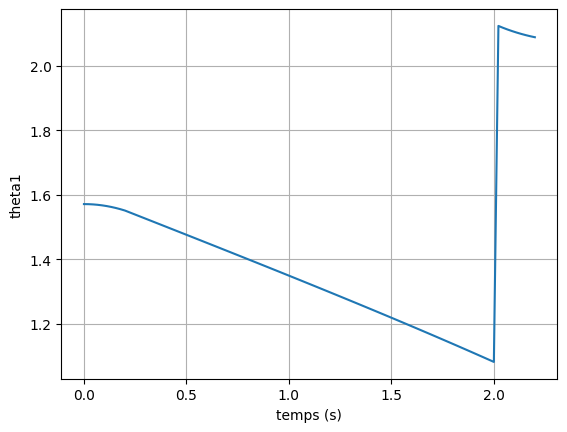

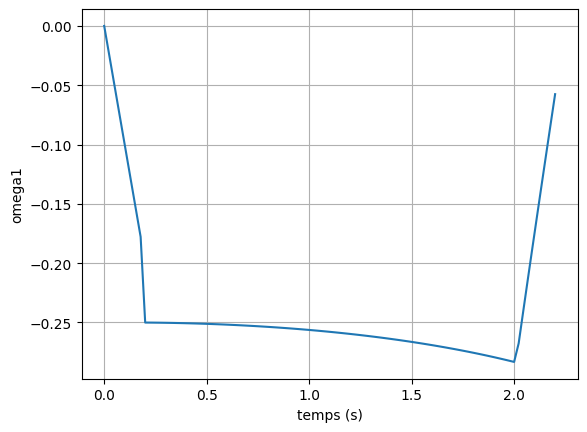

In [9]:
T=[0]
for i in range (99):
    T.append(T[i]+2.2/99)
print (len(T) ,T[0],  T[99])
Rw=[]
for t in T:
    if t<0.2:
        R=t**2 #1/2 * 2 * t**2
    elif t<2.0:
        R=0.2**2+0.5*(t-0.2)
    else :
        R=0.2**2+0.5*1.8+0.5*(t-2)-0.5*2*(t-2)**t-2
    Rw.append(R+0.5)
Vw=[]
for t in T:
    if t<0.2:
        V=2*t
    elif t<2.0:
        V=0.5
    else :
        V=0.5-2*(t-2)
    Vw.append(V)
import numpy as np
O1=[]
for R in Rw:
    cosO=(R-0.5)/2
    cosO=min(1, max(-1, cosO))
    O=np.arccos(cosO)
    O1.append(O)

W1=[]
for O,V in zip(O1, Vw):
    W=-V/(2*np.sin(O))
    W1.append(W)
#import matplotlib.pylot as plt 
plt.figure()
plt.plot(T, O1)
plt.xlabel("temps (s)")
plt.ylabel("theta1")
plt.grid(True)
plt.show()
plt.figure()
plt.plot(T, W1)
plt.xlabel("temps (s)")
plt.ylabel("omega1")
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

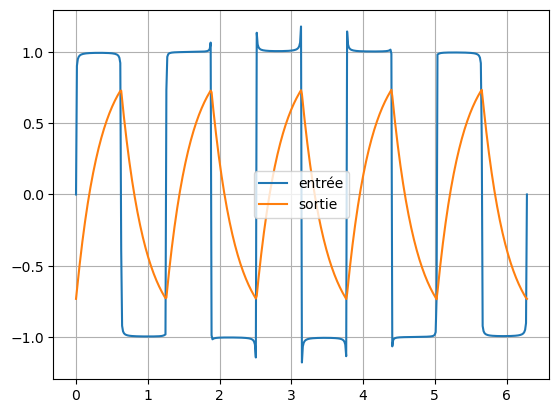

In [11]:
import numpy as np

def ondeassociee(A, phi, f):
    t=[0]
    T=[]
    d=2*np.pi/499 
    for i in range (499):
        t.append(d*(i+1))
    for p in t:
        T.append(A*np.cos(2*np.pi*f*p+phi))
    return[t,T]
    
def complexeassocie(A, phi):
    return(A*np.exp(1j*phi))

def passebas(H0,w0,w1):
    return(H0/(1+1j*w1/w0))
    
    
w0=3
w1=5
H0=1
n=50

uef=[0]*500
usf=[0]*500

for i in range(n):
    t,ue=ondeassociee(4/(np.pi*(2*i+1)), -np.pi/2, (2*i+1)*w1/(2*np.pi))
    Ue=complexeassocie(4/(np.pi*(2*i+1)),-np.pi/2)
    Us=passebas(1,3,(2*i+1)*w1)*Ue 
    us=ondeassociee(np.abs(Us), np.angle(Us), ((2*i+1)*w1/(2*np.pi)))[1]
    uef=np.array(uef)+np.array(ue)
    usf=np.array(usf)+np.array(us)


    
import matplotlib.pyplot as plt
plt.plot(t,uef,label='entrée')
plt.plot(t, usf, label='sortie')
plt.legend()
plt.grid(True)
plt.show
    

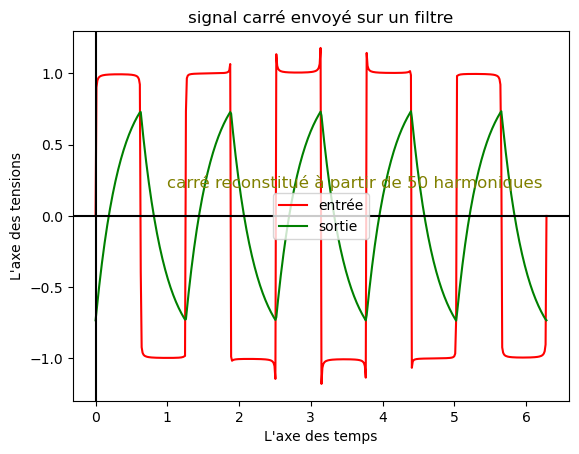

In [3]:
           ## Simulation de l'action d'un filtre sur un signal carré ##

## Principe de construction du programme

# On va reconstituer un signal carré à partir des cinquante premières harmoniques de sa décomposition de Fourier.
# On considère dans un premier temps une sinusoïde de la décomposition
# On identifie son complexe associé
# On trouve le complexe associé en sortie de filtre
# On identifie la sinusoïde associée à ce dernier complexe en sortie de filtre
# On fait la somme des cinquante sinusoïdes de sortie
# On trace les graphes des signaux d'entrée et de sortie.

## Exemple: reconstitution du signal carré à partir de sa décomposition de Fourier.

#def carre(t):
#    A=1
#    f=0.1
#    phi=0
#    u=0
#    for i in range(n):
#        u=u+4*A/Pi*(1/(2*i+1))*np.sin(2*Pi*f*t*(2*i+1)+phi)
#    return u


## Importation des modules utiles et notations

import matplotlib.pyplot as plt
import numpy as np
Pi=np.pi # nombre pi
j=complex(0,1) # complexe i

## Définitions des fonctions qui vont servir

def complexeassocie(A,phi): # on définit le nombre complexe d'amplitude A et d'argument phi
    return A*np.exp(j*phi)


def ondeassociee(A,phi,f): # on a pour image du complexe A exp(j*phi) -à la fréquence f - deux listes: listes qui définissent la sinusoïde associée, abscisse = temps et ordonnée= tension
    t=np.linspace(0,2*Pi,500)
    y=[A*np.cos(2*Pi*f*s+phi)for s in t]
    liste=[t,y]
    return liste

def passebande(H0,Q,w0,w1): # fonction de transfert canonique d'un passe-bande: H0/(1+j*Q*(w1/w0-w0/w1)) d'amplitude H0, de facteur de qualité Q, centré sur la pulsation w0 et attaqué par un signal de pulsation fondamentale w1
    return H0/(1+j*Q*(w1/w0-w0/w1))

def passebas(H0,w0,w1): # fonction de transfert canonique d'un passe-bas: H0/(1+j*w1/w0) d'amplitude H0,de pulsation de coupure w0 et attaqué par un signal de pulsation fondamentale w1
    return H0/(1+j*(w1/w0))

def passehaut(H0,w0,w1): # fonction de transfert canonique d'un passe-haut: (H0*j*(w1/w0))/(1+j*w1/w0) d'amplitude H0,de pulsation de coupure w0 et attaqué par un signal de pulsation fondamentale w1
    return (H0*j*(w1/w0))/(1+j*(w1/w0))

def sommeliste(liste1,liste2): # on définit la somme terme à terme de deux listes
    listesomme=[]
    for k in range(len(liste1)):
        listesomme=listesomme+[liste1[k]+liste2[k]]
    return listesomme

## Initialisation des listes et choix des paramètres

n=50 # On choisit de reconstituer le carré à partir de 50 sinusoïdes
A=1  # Amplitude du signal carré
H0=1 # Gain maximum des filtres utilisés
w0=3 # Pulsation caractéristique des filtres utilisés
w1=5 # Pulsation fondamentale du signal carré envoyé.
Q=15 # Facteur de qualité

usomme1=[0 for s in np.linspace(0,2*Pi,500)] # Initialisation de la liste des tensions d'entrée
usomme2=[0 for s in np.linspace(0,2*Pi,500)] # Initialisation de la liste des tensions de sortie

## Construction des deux listes de tensions, tension d'entrée et tension de sortie

for i in range(n): # On passe en revue successivement les 50 sinusoïdes
    t,u1=ondeassociee(4*A/(Pi)*(1/(2*i+1)),-Pi/2,w1*(2*i+1)/(2*Pi)) # [liste des temps, liste des tensions d'entrée]
    Ue=complexeassocie(4*A/(Pi)*(1/(2*i+1)),-Pi/2) # complexe d'entrée associé à la sinusoïde d'entrée
    Us=passebas(1,3,w1*(2*i+1))*Ue # complexe de sortie associé à la sinusoïde d'entrée
    u2=ondeassociee(np.abs(Us),np.angle(Us,deg=False),w1*(2*i+1)/(2*Pi))[1] # [liste des tensions de sortie]
    usomme1=sommeliste(usomme1,u1) # Pour chaque date, on fait la somme de toutes les tensions
    usomme2=sommeliste(usomme2,u2) # Pour chaque date, on fait la somme de toutes les tensions

## Tracé des graphes : tension d'entrée et tension de sortie

plt.clf()
plt.plot(t,usomme1,color="red",label="entrée")
plt.plot(t,usomme2,color="green",label="sortie")
plt.title("signal carré envoyé sur un filtre")
plt.text(1,0.2,"carré reconstitué à partir de 50 harmoniques",fontsize=12,c="olive")
plt.xlabel("L'axe des temps")
plt.ylabel("L'axe des tensions")
plt.axhline(color="black")
plt.axvline(color="black")
plt.legend()
plt.show()